In [14]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [15]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    graph_gen,
    video_tools)


In [16]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
QA_SGG = WORK_DIR / "outputs/gu_on_sgg_union_oneframeprompt_gemma3:4b-it-qat_20250709_08:00:00.jsonl"
SGG_GRAPHS = WORK_DIR / "outputs/sgg/sgg_union_oneframeprompt_gemma3:4b-it-qat_20250708_18:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Prompts

### SGG

In [17]:
with open(WORK_DIR / "data/prompts/graph-gen/user_prompt_oneframe_per_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


You are an intelligent video comprehension model and are going to receive as input a frame extracted from a video. You need to analyze and describe the scene unfolding in the frame following these guidelines:

1. Look for recurring objects;
2. Pay attention to how the person interacts with its environment;
3. Presume the directional movement of the people and objects in the image;
4. Pay attention to the atomic and fine grained movement
5. Deduce the intentions and motives behind the actions;
6. Identify unusual actions accurately.


In [18]:
with open(WORK_DIR / "data/prompts/graph-gen/format_instructions_oneframe_per_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


Now organize the objects and relationships you identified into a formal scene graph using this format:
object1 ---- relationship ---- object2

The list of relationship predicates should be introduced by the tag <scene_graph> and terminated by the tag </scene_graph>
For example:
woman ---- sitting_on ---- chair
dog ---- lying_under ---- table
book ---- on_top_of ---- shelf

Please follow these guidelines:
1. Create an appropriate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relationships between objects
5. Verify that all objects you identified in step 1 appear in at least one relationship

Your scene graph:


### Graph understanding from the SGG

Launch script:

```bash
  python -m star_code.src.main \
  --task graph-understanding \
  --model gemma3:4b-it-qat \
  --model-options star_code/ollama_model_options.json \
  --prompt-type mcq_zs_cot \
  --sys-prompt star_code/data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt \
  --user-prompt star_code/data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v4.txt \
  --mode chat \
  --reply-file star_code/data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt \
  --dataset-type star \
  --input-file star_code/data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json \
  --stsg-file star_code/outputs/gen_stsg_videofps_gemma3:4b-it-qat_20250628_00:26:00.jsonl \
  --output-file star_code/outputs/gu_on_sgg_20250628_00:26:00_gemma3:4b-it-qat_20250629_17:27:00.jsonl 
```

In [19]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


You need to respond to reasoning questions by making logical inference on sequence of Scene-Graphs extracted from frames belonging to a video, called a Spatio-Temporal Scene Graph.

IMPORTANT CLARIFICATIONS:
- You will receive a question and Spatio-Temporal Scene-Graph
- Each Scene-Graph is a static symbolic representation of the scene unfolding in the frame
- The Scene-Graphs are ordered chronologically
- The Scene-Graph is represented as a set of tuple in the format: subject - relationship - object
- The Spatio-Temporal Scene-Graph is a cornologically sorted list of Scene-Graphs

INSTRUCTIONS:
- Read the entire Spatio-Temporal Scene-Graphs in chronological order and pay attention at the order of how events unfold.
- Read the question and reason about the answer step by step.
- In your answer include key events or relationships that help you in determing the correct answer.
- Be careful to reproduce the chosen alternative as it is presented.


In [20]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt") as f:
    pr = f.read()
    
print(pr)
    


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
{stsg}
</STSG>

Given the following question:
<Q>
{question}
<Q>

And the following alternatives:
<Alternatives>
A. {c1}
B. {c2}
C. {c3}
D. {c4}
</Alternatives>

Provide an answer to the above question reasoning step by step on the Spatio-Temporal Scene-Graph (STSG) and choosing one of the alternatives. 

In answering the question please be sure to operate according to the following guidlines:
1. Question Interpretation: Clearly state what the question is asking
2. STSG Analysis: Carefully examine the spatial and temporal relationships in the scene graph
3. Alternative Evaluation: For each option (A, B, C, D), explain whether it matches the STSG evidence
4. Reasoning: Provide clear logical step by step reasoning leading to your conclusion
5. Conclusion: Declare the logical conclusion to your reasoning in the above step
6. Consistency Check: B

In [21]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



## Loading GT

In [22]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


## Loading Generated STSG

In [23]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df


,video_id,start,end,chat_history,stsg
0,ATV2F,0.0,4.000,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 1:\n\nwoman ---- wearing ---- dress\nd...
1,9J166,9.9,17.500,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nman ---- standing_in ---- hallwa...
2,ANA5N,4.3,10.300,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nwoman ---- holding ---- cloth\nc...
3,Z6HEA,0.0,10.875,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nwoman ---- holding_and_draping -...
4,FRLW2,3.4,27.275,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nred_gas_cylinder ---- positioned...
...,...,...,...,...,...
914,HL5OP,19.0,27.900,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nFrame 1:\n\ntable ---- has_on --...
915,F9YMU,11.9,16.500,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\ndesk ---- contains ---- laptop\n...
916,1333C,8.0,13.100,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nwoman ---- standing_at ---- coun...
917,KU656,0.0,6.800,"[{'role': 'user', 'content': 'You are an intel...",\nFrame 0:\n\nboy ---- lying_on ---- bed\nbed ...


In [24]:
print(sgg_df.iloc[495]['chat_history'][0]['content'])


You are an intelligent video comprehension model and are going to receive as input a frame extracted from a video. You need to analyze and describe the scene unfolding in the frame following these guidelines:

1. Look for recurring objects;
2. Pay attention to how the person interacts with its environment;
3. Presume the directional movement of the people and objects in the image;
4. Pay attention to the atomic and fine grained movement
5. Deduce the intentions and motives behind the actions;
6. Identify unusual actions accurately.


## Loading predicted answers evaluation

In [25]:
pred_sgg_df = rp.gemma3_ans_extract(QA_SGG)


Total answers: 1046
Answers following JSON template: 1046
Percentage following JSON template: 100.00%
Answer following the template: 1042
99.62% of the total

Only 4 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


In [26]:
print(pred_sgg_df.iloc[0]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>

Frame 1:

woman ---- wearing ---- dress
dress ---- color ---- teal
woman ---- standing_in_front_of ---- mirror
mirror ---- reflecting ---- woman
mirror ---- showing ---- reflection
woman ---- holding ---- arms
arms ---- raised
woman ---- facing ---- mirror
mirror ---- located_on ---- wall
wall ---- color ---- dark
woman ---- interacting_with ---- mirror
mirror ---- displaying ---- reflection
woman ---- observing ---- reflection
woman ---- adjusting ---- arms

Frame 2:

person ---- wearing ---- shirt
person ---- wearing ---- jeans
person ---- holding ---- backpack
backpack ---- located_in ---- room
backpack ---- being_adjusted_by ---- person
person ---- standing_in_front_of ---- mirror
mirror ---- reflecting ---- person
mirror ---- reflecting ---- backpack
room ---- containing ---- mirror
room ---- containing ---- backpack
room ---- containin

In [27]:
pred_sgg_df = pred_sgg_df.loc[pred_sgg_df['contains_answer']]


In [28]:
pred_sgg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_sgg_df.loc[pred_sgg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          296        27.70%  
Sequence             288        33.68%  
Prediction           239        35.98%  
Feasibility          219        28.31%  

Average             1042        31.38%  


In [29]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        99.33%  
Sequence             291        98.97%  
Prediction           239       100.00%  
Feasibility          220        99.55%  
Overall             1048        99.43%  


### Why is the accuracy with the generated SG as base so low?

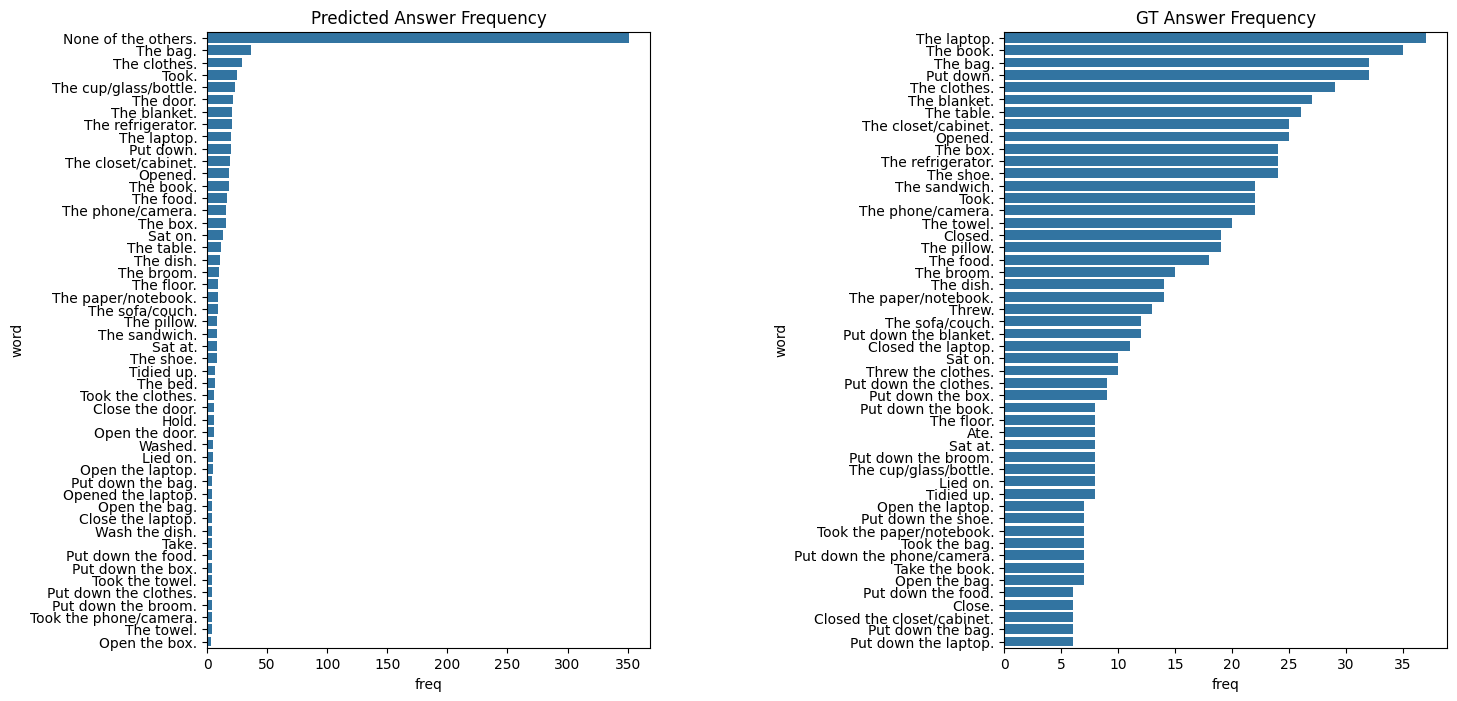

In [30]:
freq_pred = pred_sgg_df['pred_text'].value_counts().reset_index()
freq_pred.columns = ["word", "freq"]

freq_gt = gt_df['text'].value_counts().reset_index()
freq_gt.columns = ["word", "freq"]


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.8}   # adjust wspace to taste
)

sns.barplot(
    data=freq_pred.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[0]
)
axes[0].set_title("Predicted Answer Frequency")

sns.barplot(
    data=freq_gt.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[1]
)

axes[1].set_title("GT Answer Frequency")
plt.show()


That's way. For > half of the Q the model answers with None of the others.

<Axes: xlabel='freq', ylabel='word'>

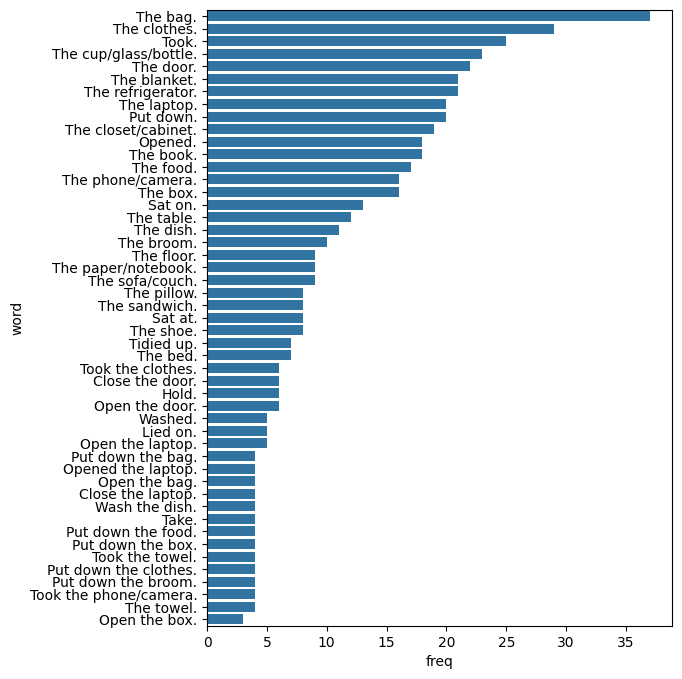

In [31]:
plt.figure(figsize=(6, 8))
sns.barplot(data=freq_pred.iloc[1:50], x='freq', y='word')


### Reasoning token length

In [32]:
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    auth_token=hugg_auth_token
)


Reasoning length:

In [33]:
reasoning_token_len_sgg = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))
reasoning_token_len_sgg.describe()


count    1042.000000
mean      624.315739
std       284.389221
min       338.000000
25%       506.000000
50%       561.500000
75%       628.750000
max      2048.000000
Name: chat_history, dtype: float64

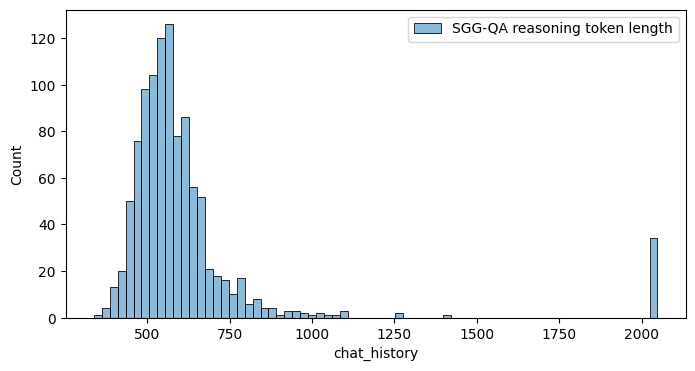

In [34]:
plt.figure(figsize=(8,4))

sns.histplot(reasoning_token_len_sgg, alpha=.5, label="SGG-QA reasoning token length")
plt.legend()


The reasoning token is not too different form other experiments.

Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [35]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB
